# EDA & ETL Showcase: Medallion Architecture

This notebook demonstrates the data transformation steps from **Silver** (Cleaned) to **Gold** (ML-Ready) using the BigQuery pipeline.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from sys import path

# Add src to path for utilities
path.append("../src")
from utils_bq import get_bq_client
from visualization.viz import plot_outlier_density, plot_rfm_distributions


## 1. Quality Layer Analysis (Raw RFM)

Before applying log transformations, we analyze the distribution of the raw features in the `rfm_2009_2010` table.

In [3]:
client = get_bq_client()
query = """
SELECT 
    sale_value, 
    frequency, 
    recency_days 
FROM `retail_segmentation.rfm_2009_2010` 
"""
df_quality = client.query(query).to_dataframe()
df_quality.describe()


c:\Users\arq_c\Desktop\ds_projects\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,sale_value,frequency,recency_days
count,4285.000000,4285.0,4285.0
mean,2016.252614,4.426138,89.548891
std,8811.212134,7.938017,96.360709
min,1.550000,1.0,0.0
25%,306.640000,1.0,17.0
50%,692.240000,2.0,51.0
75%,1699.250000,5.0,135.0
max,349164.350000,183.0,373.0


## 2. RFM Distributions & Outliers

We start with a high-level view of the histograms and boxplots for all features.

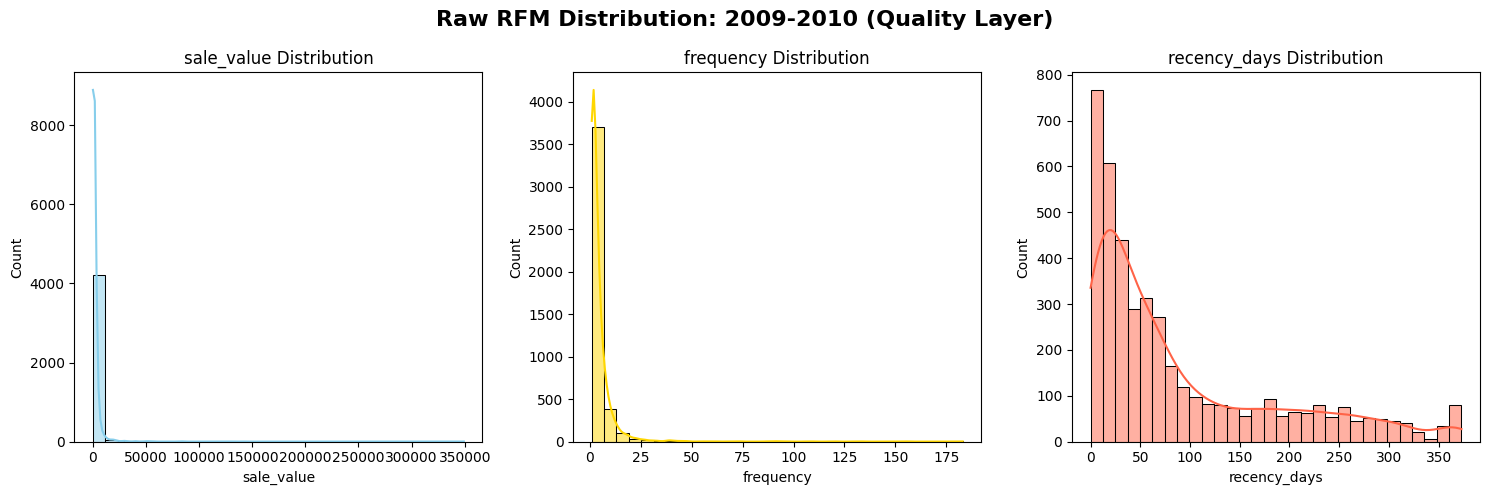

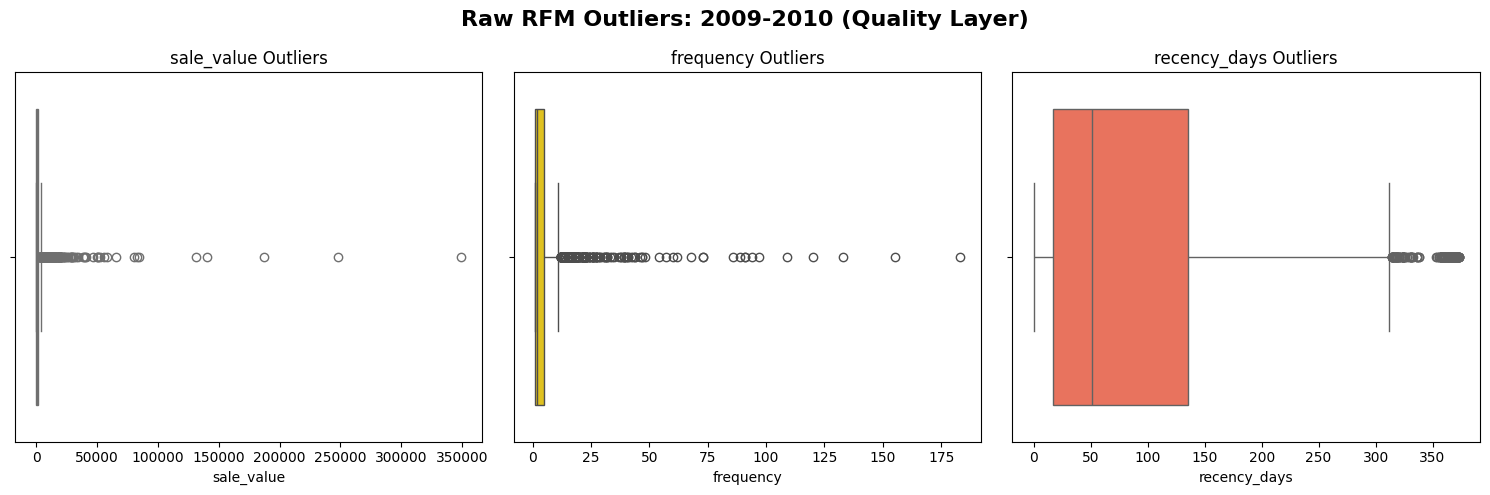

In [4]:
cols = ['sale_value', 'frequency', 'recency_days']
colors = ['skyblue', 'gold', 'tomato']

plot_rfm_distributions(
    df_quality, 
    columns=cols, 
    colors=colors, 
    hist_title='Raw RFM Distribution: 2009-2010 (Quality Layer)',
    box_title='Raw RFM Outliers: 2009-2010 (Quality Layer)'
);


## 3. Granular Outlier Density Analysis

For columns with high skewness, we apply a more detailed density analysis.

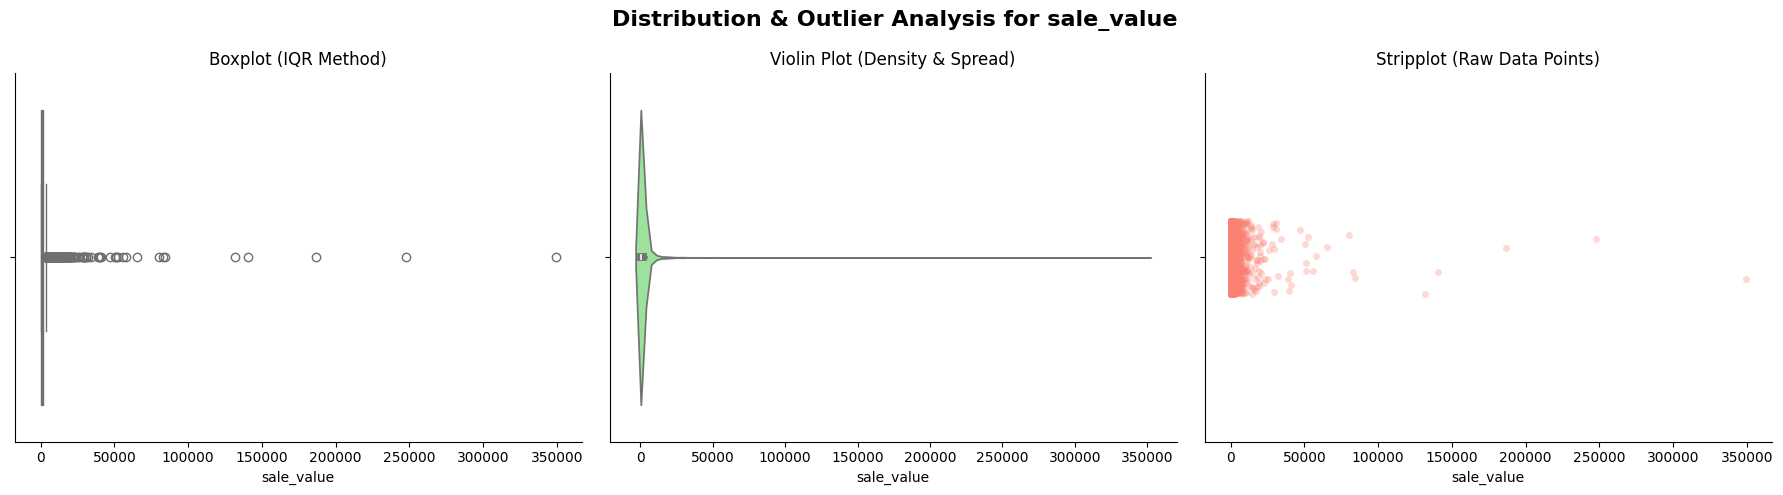

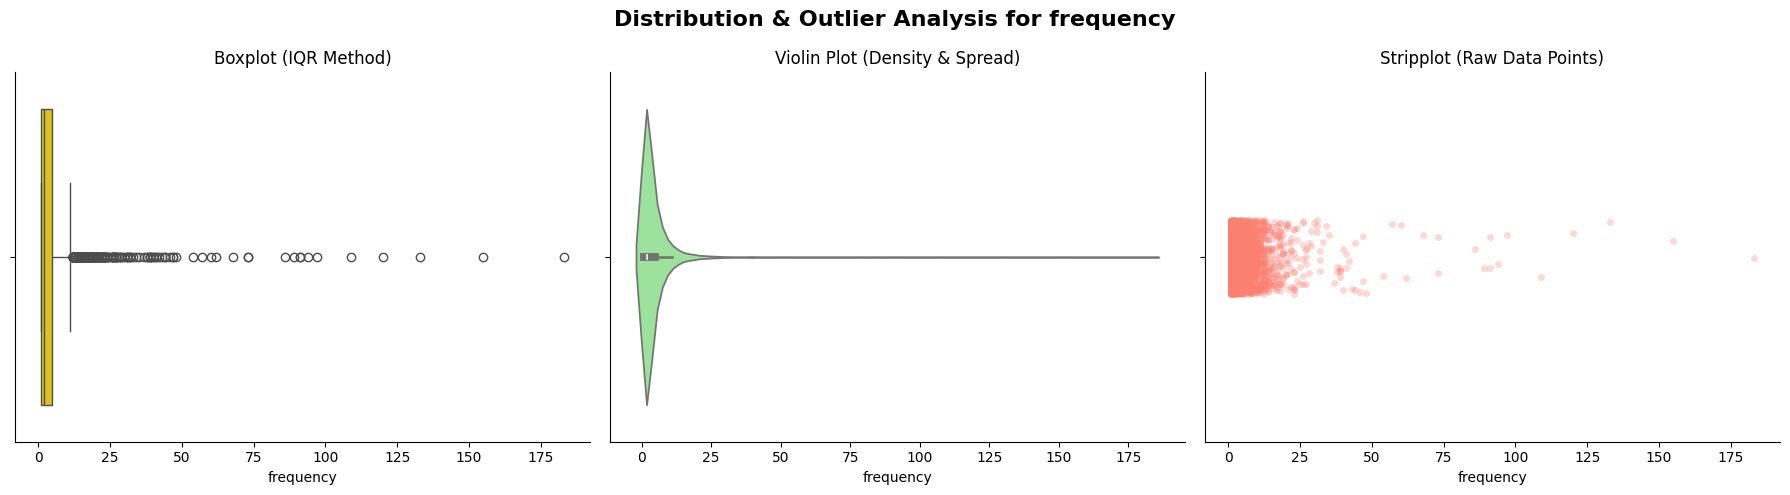

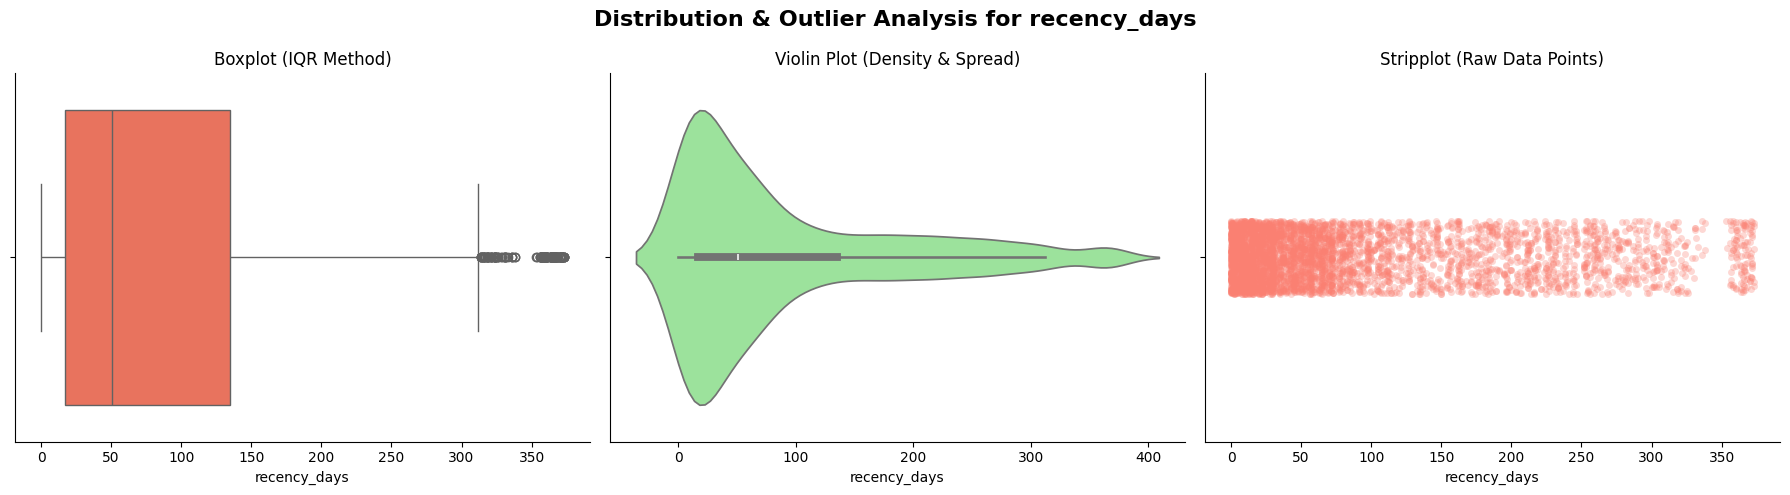

In [5]:
# Visualize Monetary (Sale Value)
plot_outlier_density(df_quality, 'sale_value', color='skyblue')

# Visualize Frequency
plot_outlier_density(df_quality, 'frequency', color='gold')

# Visualize Recency
plot_outlier_density(df_quality, 'recency_days', color='tomato')


## 4. Log-Transformed Feature Analysis (Ready Layer)

After applying log transformation ($\log(x+1)$), we verify if the distributions have become more normal and if outlier density has been reduced.

c:\Users\arq_c\Desktop\ds_projects\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


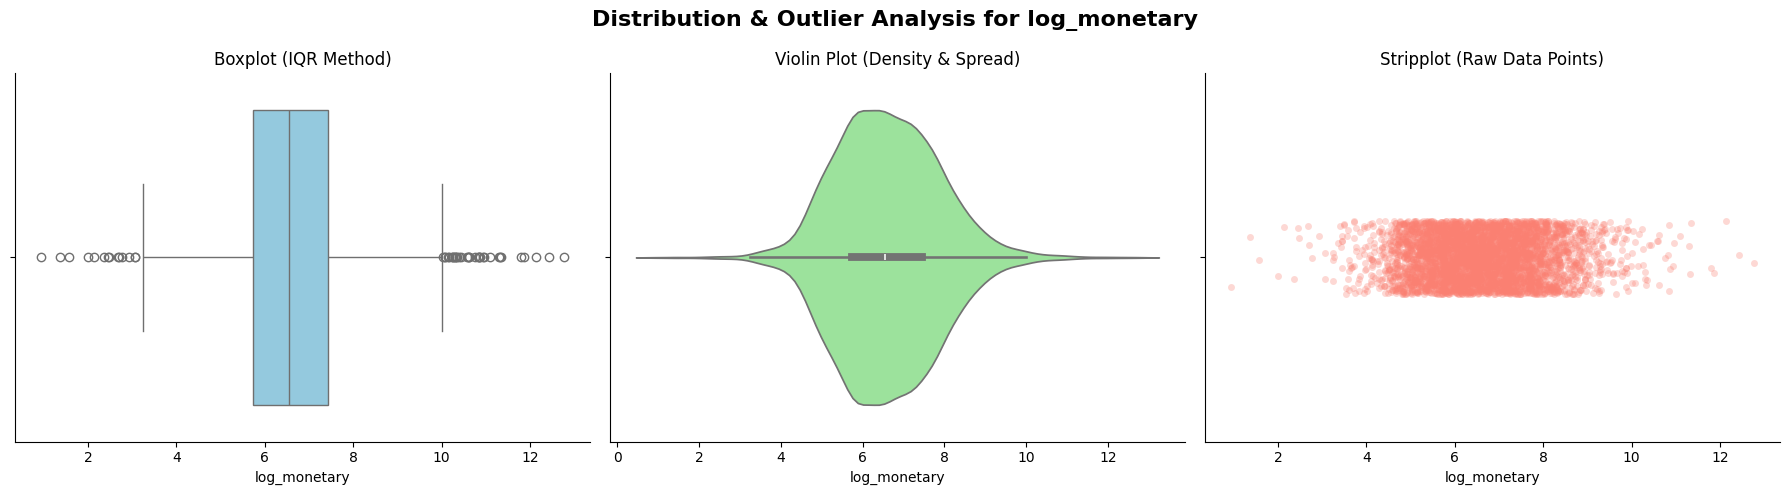

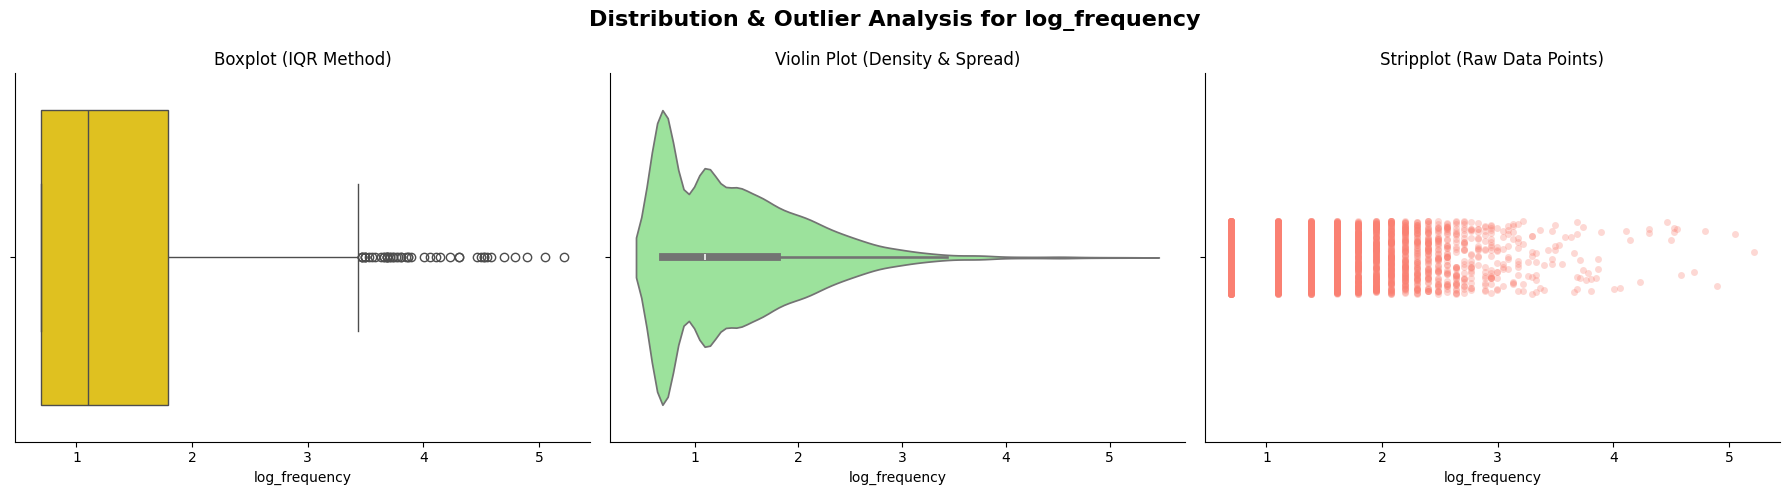

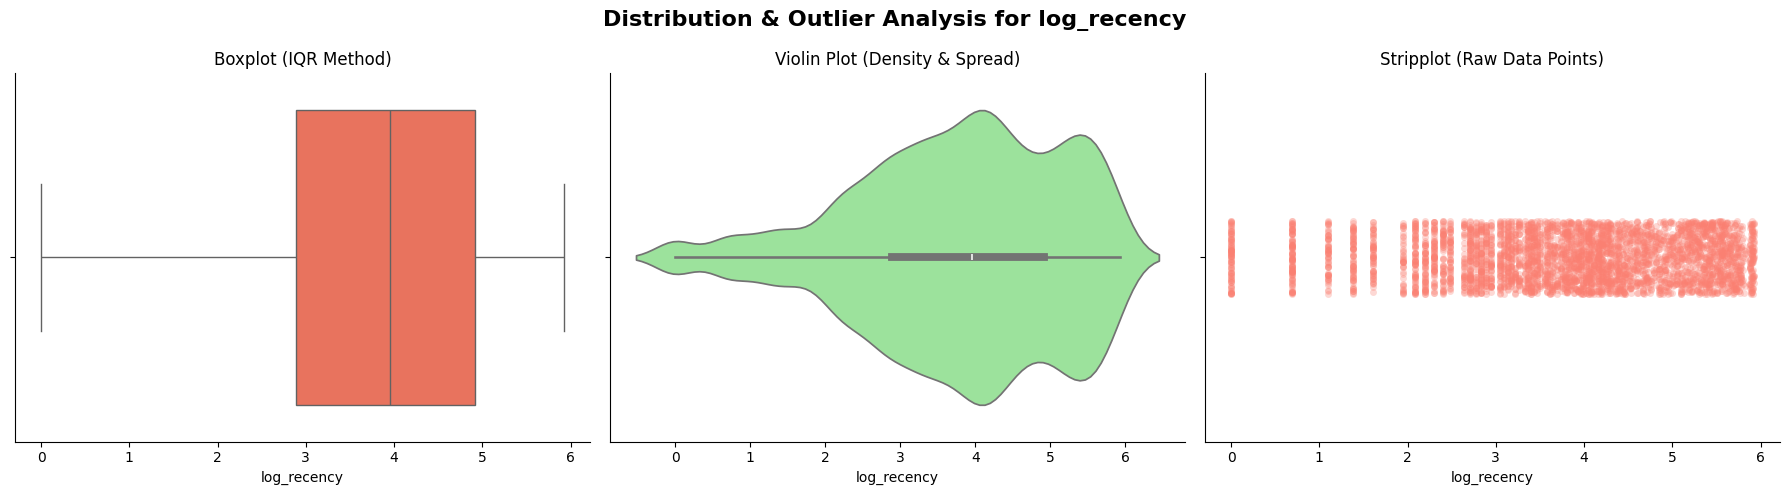

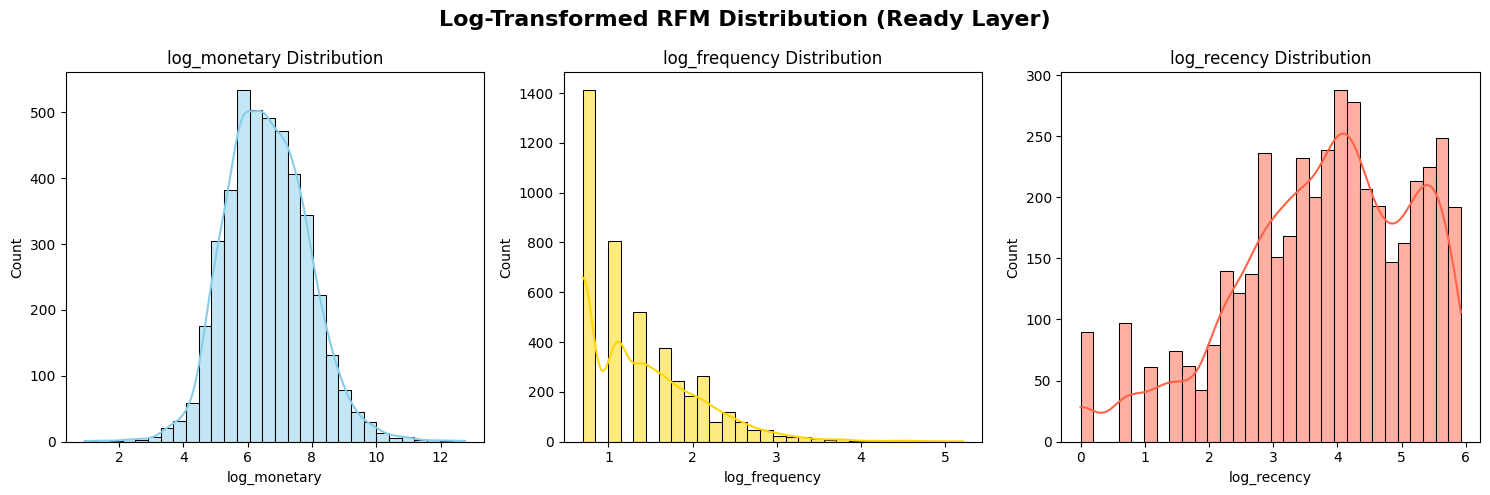

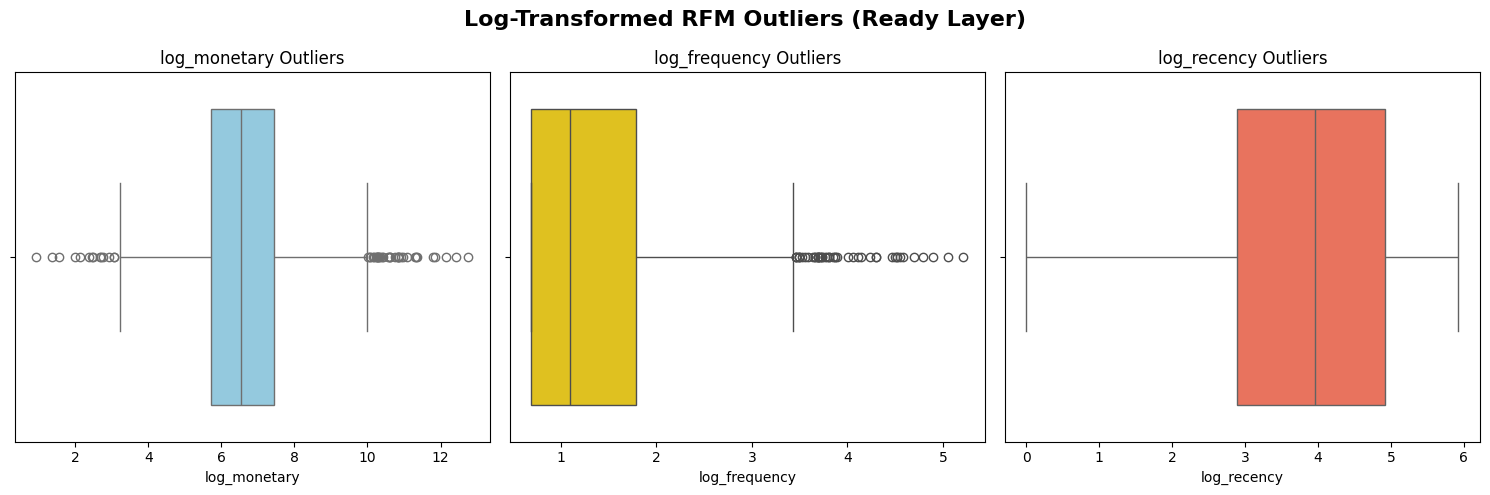

In [6]:
query_ready = """
SELECT 
    log_monetary, 
    log_frequency, 
    log_recency 
FROM `retail_segmentation.rfm_ready_2009_2010` 
"""
df_ready = client.query(query_ready).to_dataframe()

# Visualize Log-Monetary
plot_outlier_density(df_ready, 'log_monetary', color='skyblue')

# Visualize Log-Frequency
plot_outlier_density(df_ready, 'log_frequency', color='gold')

# Visualize Log-Recency
plot_outlier_density(df_ready, 'log_recency', color='tomato')

# Comprehensive Distribution Comparison
cols_log = ['log_monetary', 'log_frequency', 'log_recency']
colors_log = ['skyblue', 'gold', 'tomato']

plot_rfm_distributions(
    df_ready, 
    columns=cols_log, 
    colors=colors_log, 
    hist_title='Log-Transformed RFM Distribution (Ready Layer)',
    box_title='Log-Transformed RFM Outliers (Ready Layer)'
);
